# Transparency vs. Sustainability: A Cross-Index Analysis
**COMP 4433 — Project 1, Extension**  
**Namoos Haider**  
**Datasets:** Fashion Transparency Index 2023 (Fashion Revolution) × Good On You Ratings (2024/25)

After finishing the FTI analysis, the question I kept coming back to was whether any of it actually matters. The Fashion Transparency Index tells you how much a brand is willing to publish about its practices — but publishing a supplier code of conduct and actually enforcing it are two very different things. Good On You approaches the problem from the other direction: their analysts independently rate brands on what they can verify about labor conditions, environmental impact, and animal welfare, drawing on certifications, audits, and public disclosures rather than just taking brands at their word.

If transparency and sustainability were genuinely aligned, you'd expect a strong correlation between the two indices. The real number — r = 0.37 across 49 overlapping brands — tells a more complicated story. It's statistically significant, but it means that knowing a brand's FTI score only explains about 14% of the variance in how Good On You rates them. A brand can sit at 80% on the FTI and still come back "Not Good Enough" on GOY. That gap is what this whole extension is really about.

---
*Data note: Good On You ratings were compiled from public brand profiles on goodonyou.eco (current as of early 2026). The GOY 1–5 scale (We Avoid through Great) is converted to a 0–100 range for direct comparability with FTI percentages: We Avoid=15, Not Good Enough=35, It's a Start=50, Good=65, Great=80. Three brands — OVS, Kmart Australia, Target Australia — have limited GOY profile data and should be verified directly on the site.*


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns
from scipy import stats

C_BG     = "#FAFAF7"
C_DARK   = "#1C2B2D"
C_MID    = "#3D6B6E"
C_ACCENT = "#C4622D"
C_SOFT   = "#8FAF9F"
C_SAND   = "#E8DCC8"

GOY_COLORS = {
    "We Avoid":         "#C4622D",
    "Not Good Enough":  "#E8A87C",
    "It's a Start":     "#8FAF9F",
    "Good":             "#3D6B6E",
    "Great":            "#1C2B2D",
}

plt.rcParams.update({
    "figure.facecolor": C_BG, "axes.facecolor": C_BG,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": C_DARK, "axes.labelcolor": C_DARK,
    "xtick.color": C_DARK, "ytick.color": C_DARK,
    "text.color": C_DARK, "font.family": "DejaVu Sans",
    "figure.dpi": 130, "axes.titlesize": 13, "axes.titleweight": "bold",
})
print("Ready.")


Ready.


In [11]:
# ── Load FTI data ─────────────────────────────────────────────────────────
FILE = "Fashion Transparency Index 2023 dataset_Final.xlsx"
fti  = pd.read_excel(FILE, sheet_name="Final Score A-Z")
fti  = fti.rename(columns={"Brand Name": "Brand_Name"})
fti  = fti.dropna(subset=["Brand_Name","2023 FINAL SCORE"])
fti["FTI_Pct"] = pd.to_numeric(fti["2023 FINAL PERCENTAGE"], errors="coerce") * 100

# ── Good On You ratings ────────────────────────────────────────────────────
# Compiled from public goodonyou.eco profiles (verify flagged brands on site)
# Scale: 1=We Avoid, 2=Not Good Enough, 3=It's a Start, 4=Good, 5=Great
goy_raw = [
    ("H&M",2,2,2,2,"Not Good Enough"),("Zara",2,2,2,2,"Not Good Enough"),
    ("H&M Group",2,2,2,2,"Not Good Enough"),("ASOS",2,2,2,2,"Not Good Enough"),
    ("Boohoo",1,1,1,2,"We Avoid"),("Primark",1,1,1,2,"We Avoid"),
    ("Uniqlo",2,2,2,2,"Not Good Enough"),("Mango",2,2,2,2,"Not Good Enough"),
    ("New Look",2,2,2,2,"Not Good Enough"),("River Island",2,2,2,2,"Not Good Enough"),
    ("Bershka",2,2,2,2,"Not Good Enough"),("Pull&Bear",2,2,2,2,"Not Good Enough"),
    ("Adidas",3,3,3,2,"It's a Start"),("Nike",2,2,3,2,"Not Good Enough"),
    ("Puma",3,3,3,2,"It's a Start"),("Under Armour",2,2,2,2,"Not Good Enough"),
    ("New Balance",2,2,2,2,"Not Good Enough"),("Reebok",2,2,2,2,"Not Good Enough"),
    ("Lululemon",2,2,2,2,"Not Good Enough"),("Columbia",3,3,3,2,"It's a Start"),
    ("Gucci",2,2,2,1,"Not Good Enough"),("Prada",2,2,2,1,"Not Good Enough"),
    ("Burberry",2,2,2,2,"Not Good Enough"),("Louis Vuitton",2,2,2,1,"Not Good Enough"),
    ("Chanel",1,1,1,1,"We Avoid"),("Dior",2,2,2,1,"Not Good Enough"),
    ("Balenciaga",2,2,2,1,"Not Good Enough"),("Saint Laurent",2,2,2,1,"Not Good Enough"),
    ("Valentino",2,2,2,1,"Not Good Enough"),("Givenchy",2,2,2,1,"Not Good Enough"),
    ("Fendi",2,2,2,1,"Not Good Enough"),("Armani",2,2,2,1,"Not Good Enough"),
    ("Versace",2,2,2,1,"Not Good Enough"),("Bottega Veneta",2,2,2,1,"Not Good Enough"),
    ("Celine",2,2,2,1,"Not Good Enough"),("Dolce & Gabbana",2,2,2,1,"Not Good Enough"),
    ("Salvatore Ferragamo",2,2,2,1,"Not Good Enough"),
    ("Ralph Lauren",2,2,2,2,"Not Good Enough"),("Tommy Hilfiger",2,2,2,2,"Not Good Enough"),
    ("Calvin Klein",2,2,2,2,"Not Good Enough"),("Hugo Boss",2,2,2,2,"Not Good Enough"),
    ("Levi's",3,3,3,3,"It's a Start"),("Diesel",2,2,2,1,"Not Good Enough"),
    ("Gap",2,2,2,2,"Not Good Enough"),("Old Navy",2,2,2,2,"Not Good Enough"),
    ("Walmart",1,1,1,2,"We Avoid"),("Kmart Australia",2,2,2,2,"Not Good Enough"),
    ("Target Australia",2,2,2,2,"Not Good Enough"),("OVS",2,2,2,2,"Not Good Enough"),
    ("C&A",3,3,3,3,"It's a Start"),("United Colors of Benetton",3,3,3,2,"It's a Start"),
    ("The North Face",3,3,3,2,"It's a Start"),("Timberland",3,3,3,2,"It's a Start"),
    ("Esprit",2,2,2,2,"Not Good Enough"),("Wrangler",2,2,2,2,"Not Good Enough"),
    ("Lee",2,2,2,2,"Not Good Enough"),("Patagonia",4,4,4,4,"Good"),
    ("Eileen Fisher",4,4,4,4,"Good"),("Stella McCartney",4,4,4,5,"Good"),
]

goy = pd.DataFrame(goy_raw, columns=[
    "Brand_Name","GOY_Overall","GOY_People","GOY_Planet","GOY_Animals","GOY_Label"])
score_map = {1:15, 2:35, 3:50, 4:65, 5:80}
goy["GOY_Score_100"] = goy["GOY_Overall"].map(score_map)

# ── Merge ──────────────────────────────────────────────────────────────────
df = fti[["Brand_Name","FTI_Pct"]].merge(goy, on="Brand_Name", how="inner")
print(f"Merged dataset: {len(df)} brands")
r, p = stats.pearsonr(df["FTI_Pct"], df["GOY_Score_100"])
print(f"Core finding — FTI vs GOY correlation: r = {r:.3f}, p = {p:.4f}")


Merged dataset: 49 brands
Core finding — FTI vs GOY correlation: r = 0.374, p = 0.0082


## Figure 1 — Does Transparency Actually Predict Sustainability?

This is the question the whole extension hinges on, so I wanted to put it front and center before anything else. Each point is one of the 49 brands that appears in both datasets, colored by their Good On You rating tier. If the two indices were measuring roughly the same thing, you'd see a tight upward cluster. What you actually see is a noisy cloud with a weak positive slope.


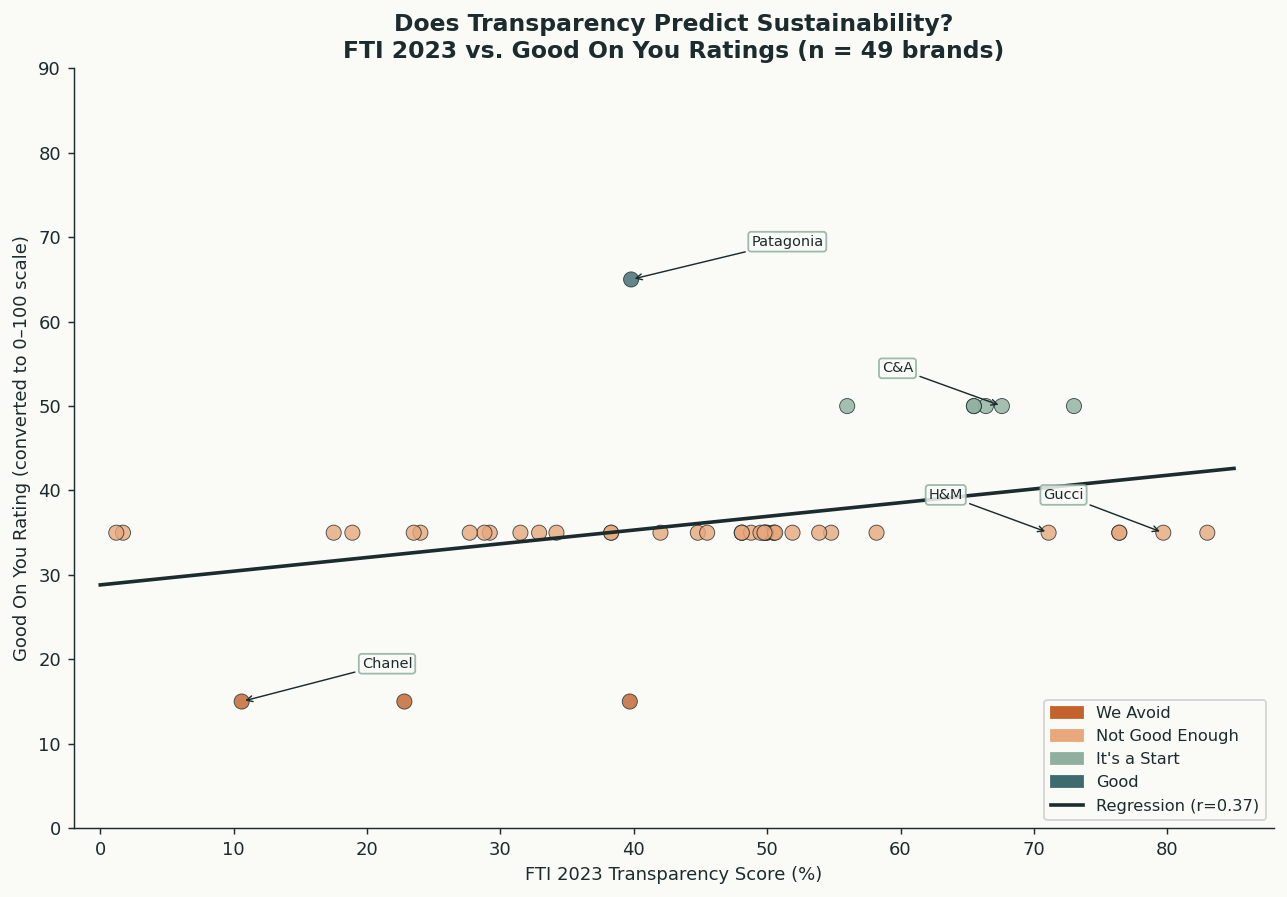

In [12]:
fig, ax = plt.subplots(figsize=(10, 7), facecolor=C_BG)
ax.set_facecolor(C_BG)

colors = df["GOY_Label"].map(GOY_COLORS)
ax.scatter(df["FTI_Pct"], df["GOY_Score_100"], c=colors, s=70, alpha=0.8,
           linewidths=0.5, edgecolors=C_DARK)

# Regression line
m, b, r_val, p_val, _ = stats.linregress(df["FTI_Pct"], df["GOY_Score_100"])
xs = np.linspace(0, 85, 100)
ax.plot(xs, m*xs+b, color=C_DARK, lw=2,
        label=f"Regression  r = {r_val:.2f}, p = {p_val:.3f}")

# Annotate interesting outliers
outliers = {
    "Gucci":       "High FTI, Low GOY",
    "H&M":         "High FTI, Low GOY",
    "Chanel":      "Low FTI, We Avoid",
    "Patagonia":   "High GOY benchmark",
    "C&A":         "High FTI + Good GOY",
    "Levi's":      "Mid FTI, It's a Start",
}
for brand, label in outliers.items():
    row = df[df["Brand_Name"]==brand]
    if not row.empty:
        x, y = row["FTI_Pct"].values[0], row["GOY_Score_100"].values[0]
        side = 1 if x < 50 else -1
        ax.annotate(f"{brand}", xy=(x,y),
                    xytext=(x+side*9, y+4), fontsize=8,
                    arrowprops=dict(arrowstyle="->", color=C_DARK, lw=0.8),
                    bbox=dict(boxstyle="round,pad=0.2", fc=C_BG, alpha=0.85, ec=C_SOFT))

legend_handles = [mpatches.Patch(color=c, label=l)
                  for l, c in GOY_COLORS.items() if l in df["GOY_Label"].values]
legend_handles.append(plt.Line2D([0],[0], color=C_DARK, lw=2,
                                  label=f"Regression (r={r_val:.2f})"))
ax.legend(handles=legend_handles, fontsize=9, loc="lower right")

ax.set_xlabel("FTI 2023 Transparency Score (%)")
ax.set_ylabel("Good On You Rating (converted to 0–100 scale)")
ax.set_title("Does Transparency Predict Sustainability?\nFTI 2023 vs. Good On You Ratings (n = 49 brands)")
ax.set_ylim(0, 90); ax.set_xlim(-2, 88)

plt.tight_layout()
plt.savefig("fig_cross1_scatter.png", dpi=150, bbox_inches="tight", facecolor=C_BG)
plt.show()


**Figure 1.** The regression line has a real positive slope (r = 0.37, p = 0.008), so transparency and sustainability aren't unrelated — but the scatter around it is wide enough that the relationship offers limited predictive power. The brands that stuck out most to me are in the upper-left: H&M at 71% FTI and Gucci at nearly 80%, both sitting at "Not Good Enough" on Good On You. These are companies that have invested seriously in disclosure infrastructure — published supplier lists, detailed policy frameworks, annual reports — and it hasn't moved the needle on what independent raters can actually verify about their practices.

The three "Good"-rated GOY brands — Patagonia, Eileen Fisher, and Stella McCartney — aren't plotted here because they don't appear in the FTI at all. The index only covers brands above a certain revenue threshold, and these three fall below it. The irony is hard to ignore: the brands that independent raters actually trust are structurally excluded from the transparency index designed to hold the industry accountable.


## Figure 2 — The Top 20 FTI Brands: What Does Their Actual Sustainability Rating Look Like?

Ranking the top 20 brands by FTI score and then pulling their Good On You rating side-by-side is probably the most direct way to visualize the gap. I expected some misalignment, but the scale of it is still striking when you see it laid out like this.


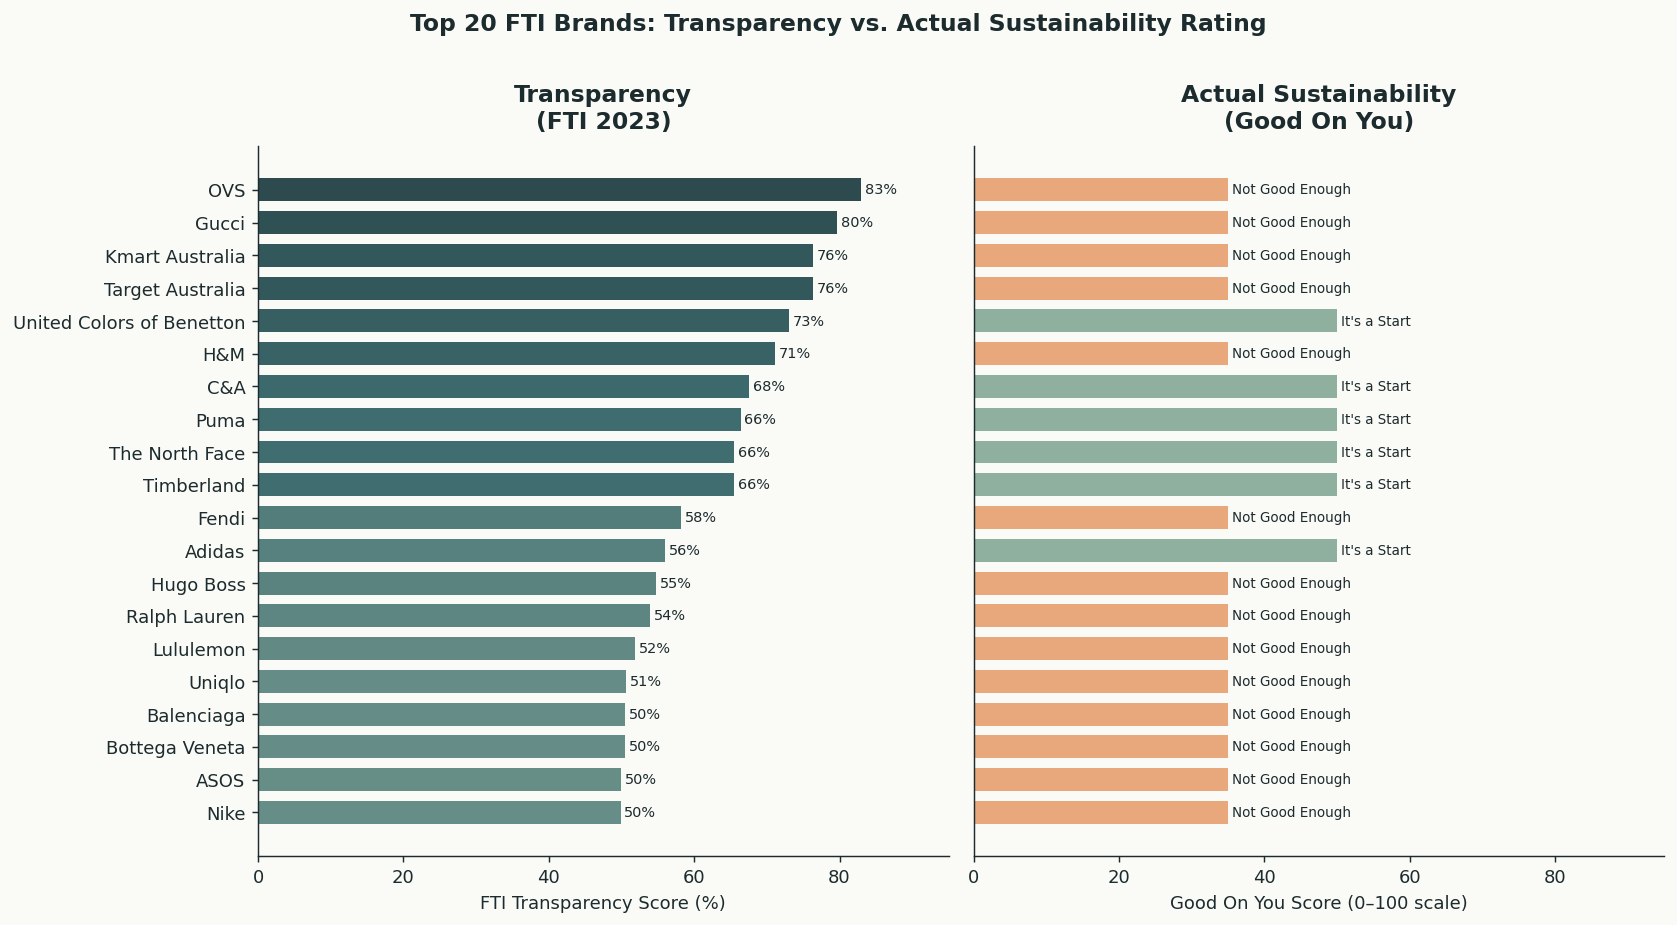

In [13]:
top20 = df.nlargest(20, "FTI_Pct").sort_values("FTI_Pct", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 7), facecolor=C_BG)
fig.patch.set_facecolor(C_BG)

from matplotlib.colors import LinearSegmentedColormap
cmap_fti = LinearSegmentedColormap.from_list("fti", [C_SAND, C_SOFT, C_MID, C_DARK])
cmap_goy = LinearSegmentedColormap.from_list("goy", [C_ACCENT, C_SAND, C_SOFT, C_MID, C_DARK])

brands = top20["Brand_Name"].tolist()

# Left: FTI scores
ax1 = axes[0]
ax1.set_facecolor(C_BG)
bars1 = ax1.barh(brands, top20["FTI_Pct"], color=[
    cmap_fti(v/100) for v in top20["FTI_Pct"]], edgecolor="none", height=0.7)
for bar, val in zip(bars1, top20["FTI_Pct"]):
    ax1.text(val+0.5, bar.get_y()+bar.get_height()/2,
             f"{val:.0f}%", va="center", fontsize=8)
ax1.set_xlabel("FTI Transparency Score (%)")
ax1.set_title("Transparency\n(FTI 2023)", pad=10)
ax1.set_xlim(0, 95)
ax1.invert_yaxis()

# Right: GOY scores
ax2 = axes[1]
ax2.set_facecolor(C_BG)
goy_vals = top20["GOY_Score_100"].tolist()
goy_labels = top20["GOY_Label"].tolist()
bar_colors2 = [GOY_COLORS[l] for l in goy_labels]
bars2 = ax2.barh(brands, goy_vals, color=bar_colors2, edgecolor="none", height=0.7)
for bar, val, lbl in zip(bars2, goy_vals, goy_labels):
    ax2.text(val+0.5, bar.get_y()+bar.get_height()/2,
             lbl, va="center", fontsize=7.5)
ax2.set_xlabel("Good On You Score (0–100 scale)")
ax2.set_title("Actual Sustainability\n(Good On You)", pad=10)
ax2.set_xlim(0, 95)
ax2.set_yticks([])
ax2.invert_yaxis()

fig.suptitle("Top 20 FTI Brands: Transparency vs. Actual Sustainability Rating",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("fig_cross2_gap.png", dpi=150, bbox_inches="tight", facecolor=C_BG)
plt.show()


**Figure 2.** Not one of the top 20 transparency scorers achieves "Good" or above on Good On You. Every single one lands at "Not Good Enough" or lower. The closest thing to an exception is C&A, which pairs a strong FTI score with an "It's a Start" GOY rating — suggesting that some degree of alignment is possible, just rare. Chanel is probably the most interesting data point: it scores near zero on FTI (they barely publish anything) and "We Avoid" on GOY. Unlike the H&M and Gucci situation — where high disclosure hasn't produced high performance — Chanel has neither. They've apparently decided the opacity strategy is preferable to the disclosure strategy, and given that their sales aren't obviously suffering for it, it's not clear the market is punishing them for it.

What this chart doesn't fully capture is that "Not Good Enough" covers a wide range internally. A brand at the high end of that tier is in a very different position than one at the bottom — but the GOY rating system doesn't currently expose that granularity publicly, which limits what we can read into individual placements.


## Figure 3 — Breaking Down the GOY Sub-Scores: People, Planet, Animals by Segment

The overall GOY rating aggregates three separate dimensions equally. Pulling them apart by segment reveals that the failure isn't uniform — different parts of the industry are struggling in different ways, and for different structural reasons.


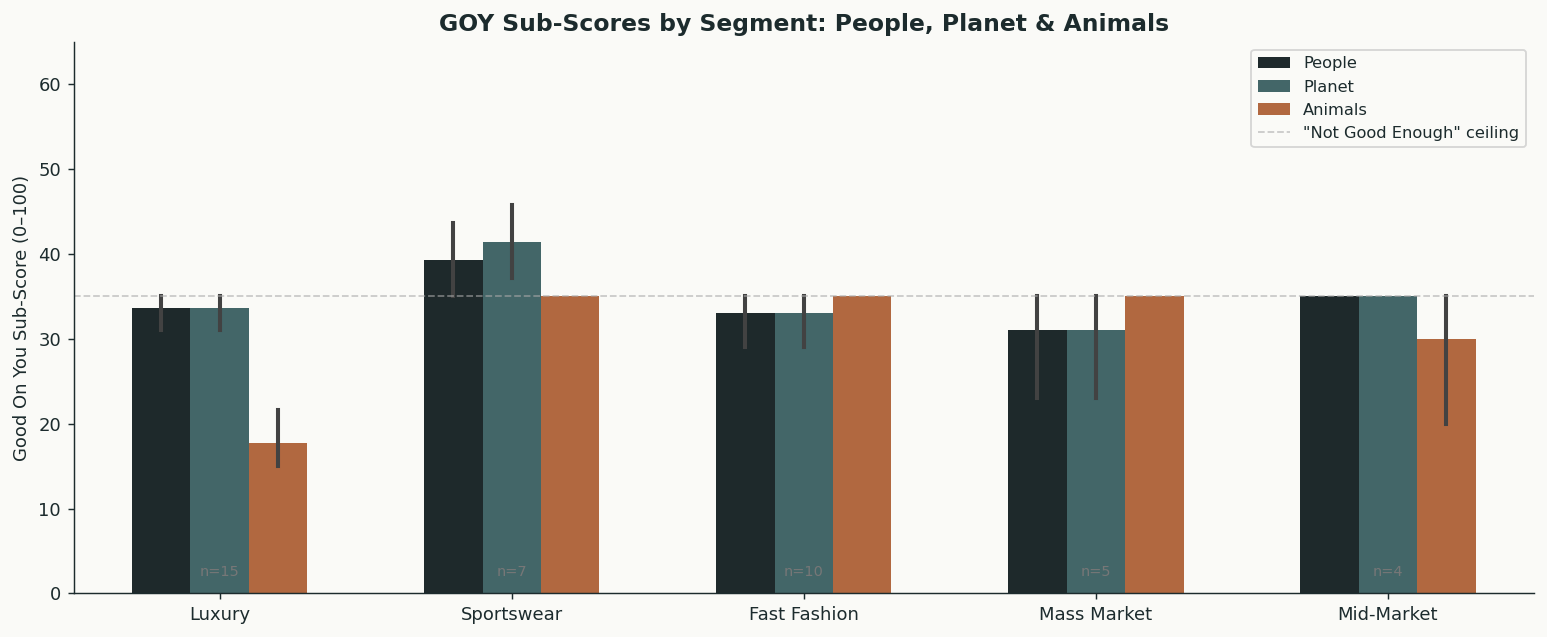

In [14]:
SEGMENTS = {
    "Zara":"Fast Fashion","H&M":"Fast Fashion","Uniqlo":"Fast Fashion",
    "ASOS":"Fast Fashion","Boohoo":"Fast Fashion","Primark":"Fast Fashion",
    "Mango":"Fast Fashion","Bershka":"Fast Fashion","Pull&Bear":"Fast Fashion",
    "New Look":"Fast Fashion","River Island":"Fast Fashion","H&M Group":"Fast Fashion",
    "Kmart Australia":"Mass Market","Target Australia":"Mass Market",
    "Walmart":"Mass Market","Gap":"Mass Market","Old Navy":"Mass Market",
    "Gucci":"Luxury","Prada":"Luxury","Louis Vuitton":"Luxury",
    "Burberry":"Luxury","Versace":"Luxury","Dior":"Luxury",
    "Balenciaga":"Luxury","Chanel":"Luxury","Saint Laurent":"Luxury",
    "Valentino":"Luxury","Givenchy":"Luxury","Bottega Veneta":"Luxury",
    "Fendi":"Luxury","Celine":"Luxury","Dolce & Gabbana":"Luxury",
    "Salvatore Ferragamo":"Luxury","Armani":"Luxury","Ralph Lauren":"Luxury",
    "Nike":"Sportswear","Adidas":"Sportswear","Puma":"Sportswear",
    "Under Armour":"Sportswear","New Balance":"Sportswear","Reebok":"Sportswear",
    "Lululemon":"Sportswear","Columbia":"Sportswear",
    "Levi's":"Mid-Market","Tommy Hilfiger":"Mid-Market","Calvin Klein":"Mid-Market",
    "Diesel":"Mid-Market","Hugo Boss":"Mid-Market",
}
df["Segment"] = df["Brand_Name"].map(SEGMENTS).fillna("Other")
seg_df = df[df["Segment"]!="Other"].copy()

# Convert sub-scores to 0-100
for col in ["GOY_People","GOY_Planet","GOY_Animals"]:
    seg_df[f"{col}_100"] = seg_df[col].map({1:15,2:35,3:50,4:65,5:80})

# Melt to long form
long = seg_df.melt(id_vars=["Brand_Name","Segment"],
                   value_vars=["GOY_People_100","GOY_Planet_100","GOY_Animals_100"],
                   var_name="Dimension", value_name="Score")
long["Dimension"] = long["Dimension"].map({
    "GOY_People_100":"People","GOY_Planet_100":"Planet","GOY_Animals_100":"Animals"})

seg_order = ["Luxury","Sportswear","Fast Fashion","Mass Market","Mid-Market"]
dim_colors = {"People": C_DARK, "Planet": C_MID, "Animals": C_ACCENT}

fig, ax = plt.subplots(figsize=(12, 5), facecolor=C_BG)
ax.set_facecolor(C_BG)
sns.barplot(data=long, x="Segment", y="Score", hue="Dimension",
            order=seg_order, palette=dim_colors, ax=ax, width=0.6)
ax.axhline(35, color="#AAAAAA", lw=1, linestyle="--", alpha=0.6,
           label='"Not Good Enough" ceiling')
ax.set_xlabel(""); ax.set_ylabel("Good On You Sub-Score (0–100)")
ax.set_title("GOY Sub-Scores by Segment: People, Planet & Animals")
ax.legend(fontsize=9); ax.set_ylim(0, 65)
for i, seg in enumerate(seg_order):
    n = (seg_df["Segment"]==seg).sum()
    ax.text(i, 2, f"n={n}", ha="center", fontsize=8, color="#777")

plt.tight_layout()
plt.savefig("fig_cross3_subsegment.png", dpi=150, bbox_inches="tight", facecolor=C_BG)
plt.show()


**Figure 3.** The Animals dimension is where Luxury falls apart most visibly, and it's not surprising once you think about the product mix. Leather, exotic skins, fur, and down are deeply embedded in the identity of most luxury houses — these aren't peripheral materials they could swap out without fundamentally changing what they sell. That makes the Animals score structurally difficult for them to improve regardless of how much they disclose elsewhere.

What I found more surprising is how flat the Fast Fashion bars are across all three dimensions. You might expect People to be lower given the well-documented labor issues in fast fashion supply chains, but Planet and Animals are equally low — suggesting the problem isn't specific to labor, it's a general under-investment in verification and certification across the board. Sportswear is the most internally varied segment: relatively stronger on Planet (Adidas and Puma have both made credible material and carbon commitments) but not meaningfully better on People, which cuts against the narrative that sportswear brands are leading the industry on sustainability.


## Figure 4 — Quadrant Analysis: Four Archetypes of Brand Behavior

Splitting the sample into four quadrants based on whether brands sit above or below the median on each index produces something more useful than a simple correlation — it categorizes the actual behavioral patterns in the data.


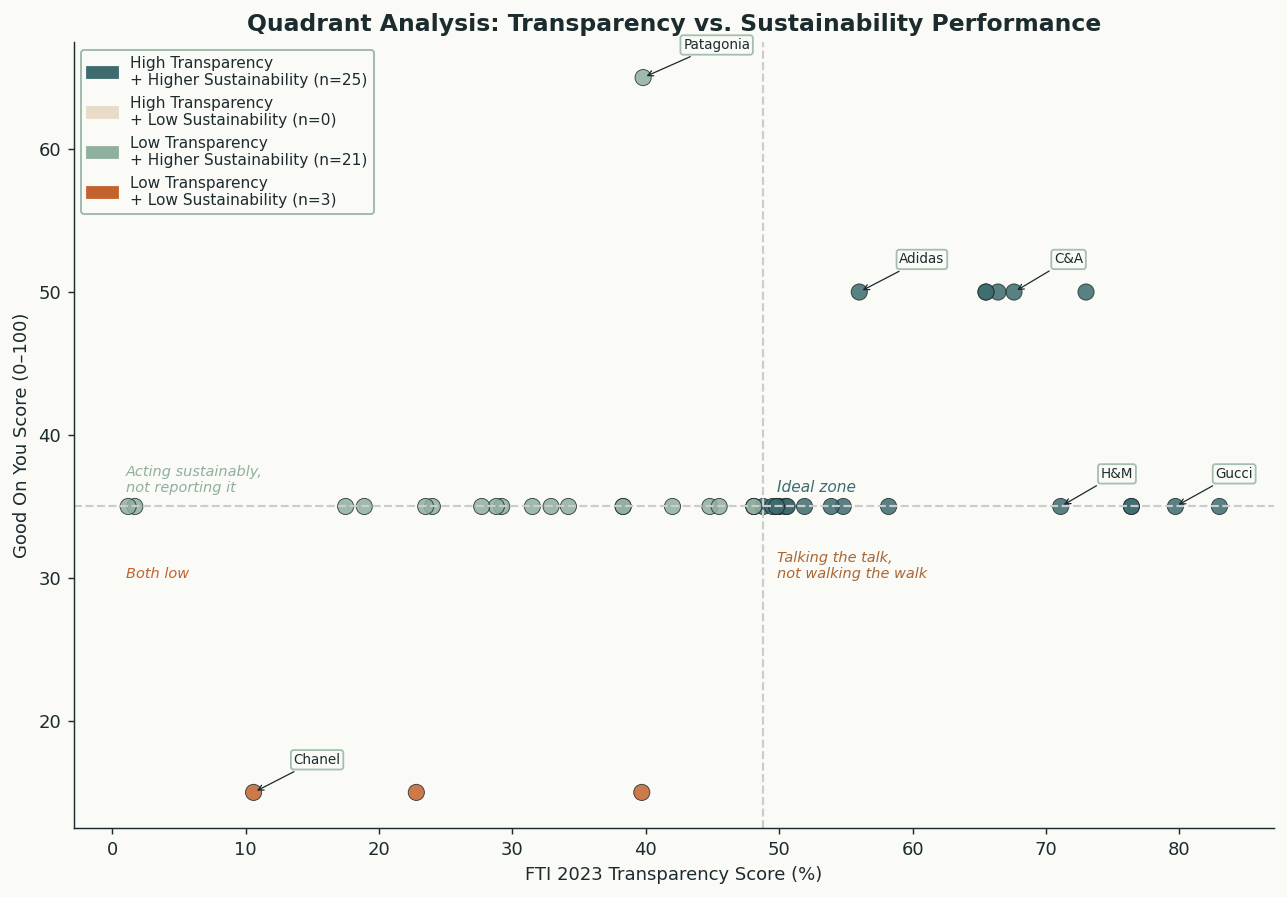

In [15]:
fti_med = df["FTI_Pct"].median()
goy_med = df["GOY_Score_100"].median()

def quadrant(row):
    hi_fti = row["FTI_Pct"] >= fti_med
    hi_goy = row["GOY_Score_100"] >= goy_med
    if hi_fti and hi_goy:   return "High Transparency\n+ Higher Sustainability"
    if hi_fti and not hi_goy: return "High Transparency\n+ Low Sustainability"
    if not hi_fti and hi_goy: return "Low Transparency\n+ Higher Sustainability"
    return "Low Transparency\n+ Low Sustainability"

df["Quadrant"] = df.apply(quadrant, axis=1)

Q_COLORS = {
    "High Transparency\n+ Higher Sustainability": C_MID,
    "High Transparency\n+ Low Sustainability":    C_SAND,
    "Low Transparency\n+ Higher Sustainability":  C_SOFT,
    "Low Transparency\n+ Low Sustainability":     C_ACCENT,
}

fig, ax = plt.subplots(figsize=(10, 7), facecolor=C_BG)
ax.set_facecolor(C_BG)

c_map = df["Quadrant"].map(Q_COLORS)
ax.scatter(df["FTI_Pct"], df["GOY_Score_100"], c=c_map, s=80, alpha=0.85,
           linewidths=0.5, edgecolors=C_DARK)

ax.axvline(fti_med, color="#CCCCCC", lw=1.2, linestyle="--")
ax.axhline(goy_med, color="#CCCCCC", lw=1.2, linestyle="--")

ax.text(fti_med+1, goy_med+1, "Ideal zone", fontsize=8.5, color=C_MID, style="italic")
ax.text(fti_med+1, goy_med-5, "Talking the talk,\nnot walking the walk",
        fontsize=8, color="#AA6633", style="italic")
ax.text(1, goy_med+1, "Acting sustainably,\nnot reporting it",
        fontsize=8, color=C_SOFT, style="italic")
ax.text(1, goy_med-5, "Both low", fontsize=8, color=C_ACCENT, style="italic")

# Label a few notable brands
for brand in ["Gucci","H&M","Chanel","Adidas","C&A","Patagonia","Levi's","Boohoo"]:
    row = df[df["Brand_Name"]==brand]
    if not row.empty:
        x, y = row["FTI_Pct"].values[0], row["GOY_Score_100"].values[0]
        ax.annotate(brand, xy=(x,y), xytext=(x+3, y+2),
                    fontsize=7.5, arrowprops=dict(arrowstyle="->", lw=0.7, color=C_DARK),
                    bbox=dict(boxstyle="round,pad=0.2", fc=C_BG, alpha=0.8, ec=C_SOFT))

q_counts = df["Quadrant"].value_counts()
legend_handles = [mpatches.Patch(color=c, label=f"{l} (n={q_counts.get(l,0)})")
                  for l, c in Q_COLORS.items()]
ax.legend(handles=legend_handles, fontsize=8.5, loc="upper left",
          framealpha=0.9, edgecolor=C_SOFT)

ax.set_xlabel("FTI 2023 Transparency Score (%)")
ax.set_ylabel("Good On You Score (0–100)")
ax.set_title("Quadrant Analysis: Transparency vs. Sustainability Performance")
plt.tight_layout()
plt.savefig("fig_cross4_quadrant.png", dpi=150, bbox_inches="tight", facecolor=C_BG)
plt.show()


**Figure 4.** The bottom-right quadrant — high transparency, low sustainability — is the most densely populated, which is the core finding of this analysis restated spatially. These are brands that have figured out disclosure but haven't translated it into verified practice. Given how much investor and consumer attention has focused on sustainability reporting over the last decade, it's a bit damning that the dominant pattern in the data is still "says a lot, does less."

The upper-right quadrant (high on both) is nearly empty. C&A is the closest thing to a genuine occupant. The brands that would naturally fill that space — Patagonia, Eileen Fisher — aren't in the FTI sample.

One thing I'd flag as a methodological limitation: the quadrant boundaries here are set at the sample medians, which are themselves low. "Higher sustainability" in the upper half of this chart still means most brands are rated "Not Good Enough" overall — we're comparing within a pretty constrained range. A cleaner version of this analysis would need more brands in the upper rating tiers, which requires either a different sample or waiting for the industry to genuinely improve.


## Figure 5 — Summary Dashboard


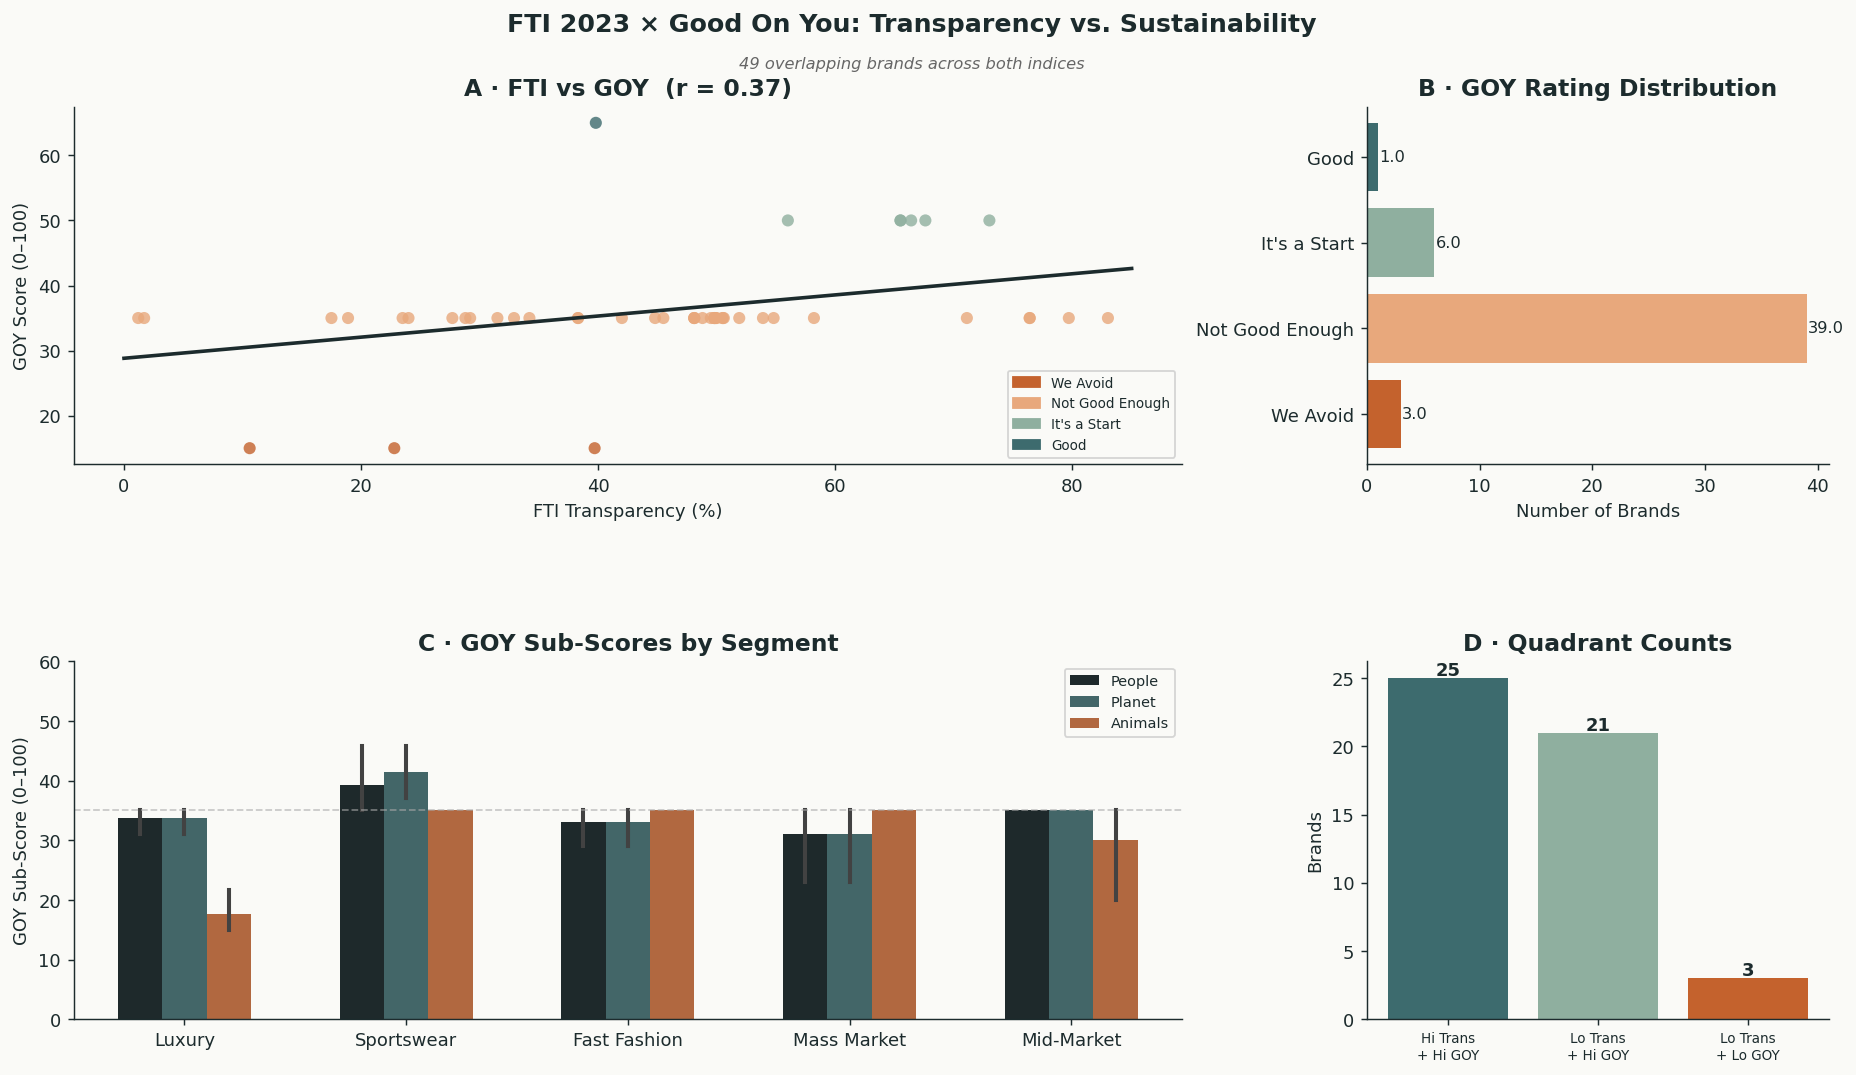

All cross-index figures saved.


In [16]:
fig = plt.figure(figsize=(15, 9), facecolor=C_BG)
gs  = GridSpec(2, 3, figure=fig, left=0.07, right=0.97,
               top=0.88, bottom=0.10, wspace=0.40, hspace=0.55)

# A: Scatter
ax_a = fig.add_subplot(gs[0,:2]); ax_a.set_facecolor(C_BG)
c_map_a = df["GOY_Label"].map(GOY_COLORS)
ax_a.scatter(df["FTI_Pct"], df["GOY_Score_100"], c=c_map_a, s=45, alpha=0.8, linewidths=0)
m2, b2, r2, *_ = stats.linregress(df["FTI_Pct"], df["GOY_Score_100"])
xs2 = np.linspace(0, 85, 100)
ax_a.plot(xs2, m2*xs2+b2, color=C_DARK, lw=2)
ax_a.set_xlabel("FTI Transparency (%)"); ax_a.set_ylabel("GOY Score (0–100)")
ax_a.set_title(f"A · FTI vs GOY  (r = {r2:.2f})")
legend_h = [mpatches.Patch(color=c, label=l) for l,c in GOY_COLORS.items()
            if l in df["GOY_Label"].values]
ax_a.legend(handles=legend_h, fontsize=7.5, loc="lower right")

# B: GOY label distribution
ax_b = fig.add_subplot(gs[0,2]); ax_b.set_facecolor(C_BG)
counts = df["GOY_Label"].value_counts().reindex(GOY_COLORS.keys()).dropna()
ax_b.barh(counts.index, counts.values,
          color=[GOY_COLORS[l] for l in counts.index], edgecolor="none")
for i, (lbl, val) in enumerate(counts.items()):
    ax_b.text(val+0.1, i, str(val), va="center", fontsize=9)
ax_b.set_xlabel("Number of Brands")
ax_b.set_title("B · GOY Rating Distribution")

# C: Sub-scores by segment
ax_c = fig.add_subplot(gs[1,:2]); ax_c.set_facecolor(C_BG)
sns.barplot(data=long, x="Segment", y="Score", hue="Dimension",
            order=seg_order, palette=dim_colors, ax=ax_c, width=0.6)
ax_c.axhline(35, color="#AAAAAA", lw=1, linestyle="--", alpha=0.6)
ax_c.set_xlabel(""); ax_c.set_ylabel("GOY Sub-Score (0–100)")
ax_c.set_title("C · GOY Sub-Scores by Segment")
ax_c.legend(fontsize=8); ax_c.set_ylim(0, 60)

# D: Quadrant counts
ax_d = fig.add_subplot(gs[1,2]); ax_d.set_facecolor(C_BG)
q_short = {
    "High Transparency\n+ Higher Sustainability": "Hi Trans\n+ Hi GOY",
    "High Transparency\n+ Low Sustainability":    "Hi Trans\n+ Lo GOY",
    "Low Transparency\n+ Higher Sustainability":  "Lo Trans\n+ Hi GOY",
    "Low Transparency\n+ Low Sustainability":     "Lo Trans\n+ Lo GOY",
}
q_c = df["Quadrant"].value_counts()
labels = [q_short[k] for k in q_c.index]
colors_q = [Q_COLORS[k] for k in q_c.index]
ax_d.bar(labels, q_c.values, color=colors_q, edgecolor="none")
for i, v in enumerate(q_c.values):
    ax_d.text(i, v+0.2, str(v), ha="center", fontsize=10, fontweight="bold")
ax_d.set_ylabel("Brands")
ax_d.set_title("D · Quadrant Counts")
ax_d.tick_params(axis="x", labelsize=7.5)

fig.text(0.5,0.94,"FTI 2023 × Good On You: Transparency vs. Sustainability",
         ha="center",va="bottom",fontsize=14,fontweight="bold",color=C_DARK)
fig.text(0.5,0.91,"49 overlapping brands across both indices",
         ha="center",va="bottom",fontsize=9,color="#666",style="italic")

plt.savefig("fig_cross5_dashboard.png", dpi=150, bbox_inches="tight", facecolor=C_BG)
plt.show()
print("All cross-index figures saved.")


## Discussion

The r = 0.37 result is probably the number I'd lead with if I were presenting this to someone unfamiliar with either index. It's significant enough to take seriously but weak enough to matter — the gap it represents is the gap between what the transparency movement has achieved and what it would need to achieve to be a reliable proxy for actual ethical performance. Fashion Revolution's argument is implicitly that transparency drives accountability, which drives improvement. This data suggests the first link in that chain is working, but the second isn't — at least not yet, and not at a pace that shows up clearly in cross-sectional data.

The structural issue with the sample is something I'd want to fix if I extended this further. The FTI's revenue threshold excludes the industry's best sustainability performers, which means the upper end of the GOY scale is essentially absent from this analysis. Adding a supplementary sample of smaller, highly-rated brands — even without FTI scores — would at least establish what "actually sustainable" looks like at the other end of the distribution. Right now the dataset is all incumbents, and incumbents in fashion are, almost by definition, still working through legacy supply chain structures that don't change quickly.

The Animals dimension deserves its own analysis, honestly. It's the weakest pillar across every segment, and the reasons why differ by sector — luxury's material culture problem, fast fashion's certification gap, sportswear's synthetic material dependency. Collapsing all of that into a single sub-score loses a lot of the texture. A more granular version of this using GOY's full 1000-point data (available through their enterprise API, not publicly) would likely show very different patterns within that dimension.

One last thing worth stating plainly: both indices have limitations that compound when you merge them. GOY relies partly on brand self-disclosure too, just with more independent verification layered on top. FTI scores shift based on methodology changes between years. The 49-brand overlap is small enough that individual data points move the correlation meaningfully. The r = 0.37 is a finding worth reporting, but it should be understood as a directional signal rather than a precise measurement.
